# Block 4: Deep-Learning and Feature Extraction

Now that we have worked through the basic image processing techniques, we will dive into the limitations that can be noticed using those techniques on real world data. We will then take a look at how newer techniques such as machine learning methods can help us where data is a bit trickier to process.

After using state-of-the-art models, we will look into what features we can extract from our images, and how we can represent them using Python.

## Thresholding On Real-World Data

As seen in Block 3, thresholding methods work very well on datasets and images that are evenly lit, and where the contrast between background and foreground is clear. Unfortunately, this is not always the case with real-world microscopy images. We encounter cases where some nuclei are missing signal and where some cells are very faint on a daily basis. Let's take a look at an example.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage import filters
import pandas as pd

from skimage.measure import regionprops_table

from cellpose import models
from cellpose.io import imread

# Set seaborn defaults
sns.set_theme(style="whitegrid")

Image shape: (3, 1011, 1557)


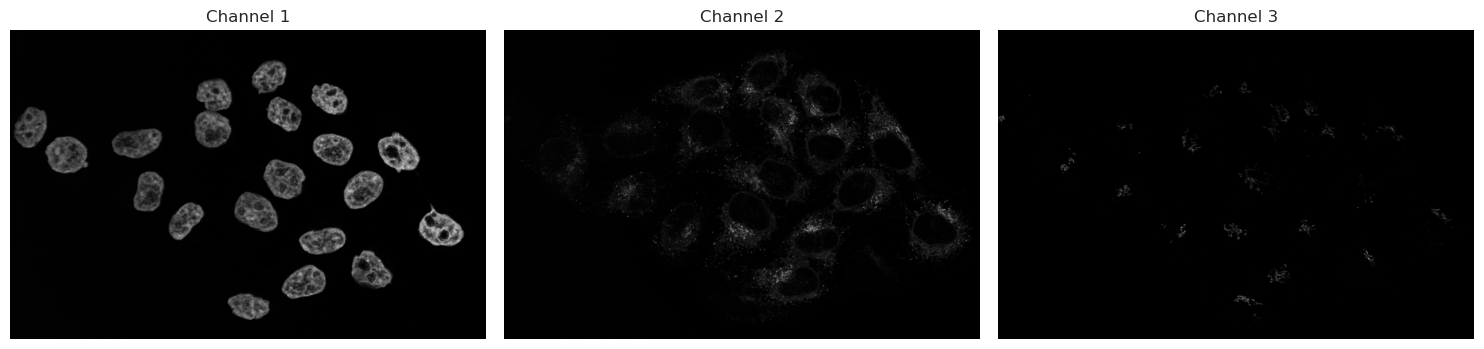

In [2]:
raw_img = "../data/rab9a-egfp-slice-cropped.tif"
# We can use cellpose's imread function to read the image
img = imread(raw_img)

# With img.shape, we can check the dims of the image and number of channels
print(f"Image shape: {img.shape}")

# As this is a 3-channel image, we can visualize each channel separately
fig, ax = plt.subplots(1, 3, figsize=(15, 15))

ax[0].imshow(img[0], cmap="gray")
ax[0].set_title("Channel 1")
ax[0].axis("off")

ax[1].imshow(img[1], cmap="gray")
ax[1].set_title("Channel 2")
ax[1].axis("off")

ax[2].imshow(img[2], cmap="gray")
ax[2].set_title("Channel 3")
ax[2].axis("off")

plt.tight_layout()
plt.show()


Let's analyse the nuclei first in Channel 1. As discussed before, we start with a threshold to then make objects.

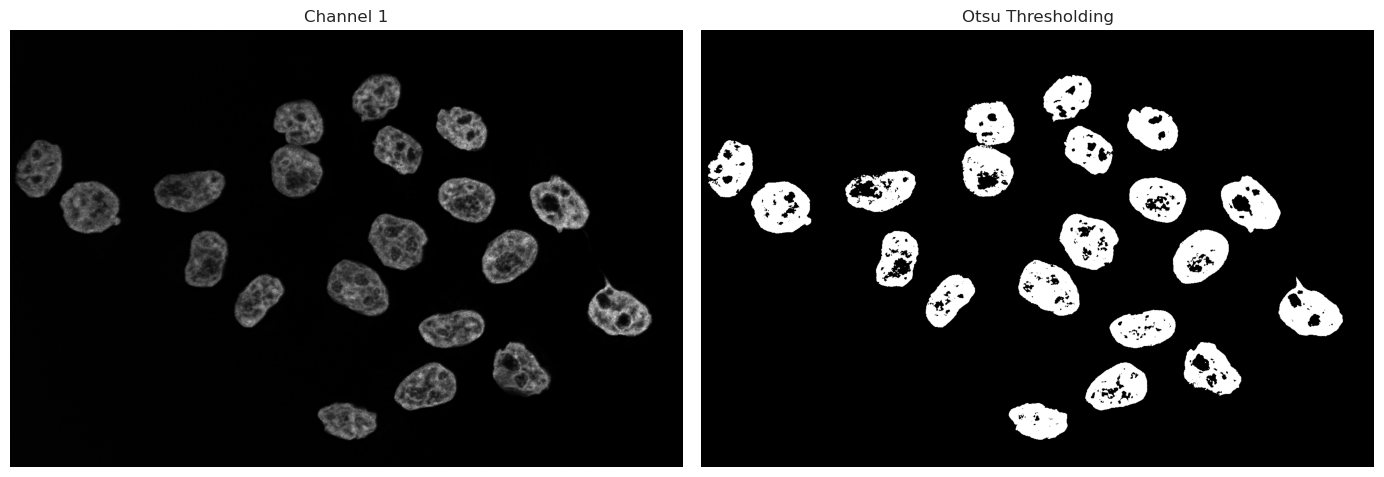

In [3]:
img_ch1 = img[0]
img_ch2 = img[1]
# Let's use Otsu's method on channel 1
img_ch1_otsu_t = filters.threshold_otsu(img_ch1)

# Keep only those that are above the threshold
binary_ch1 = img_ch1 > img_ch1_otsu_t
fig, ax = plt.subplots(1, 2, figsize=(14, 8))

# Plotting code
ax[0].imshow(img_ch1, cmap="gray")
ax[0].set_title("Channel 1")
ax[0].axis("off")

ax[1].imshow(binary_ch1, cmap="gray")
ax[1].set_title("Otsu Thresholding")
ax[1].axis("off")
plt.tight_layout()
plt.show()

As we can see, the binary image has some "holes" in the nuclei due to dim or even no signal being captured inside the nucleus. There are multiple ways we could go about fixing this. **Morphological operations** are simple image-processing techniques that change the shape of objects in a binary image by adding or removing pixels based on their neighbors. These operations can help clean up segmentation results by filling holes or removing small artifacts.

Operations such as closing can fill small gaps inside objects, while opening operations can remove small signals of noise. These methods work only on a binary image and can be used quickly to improve thresholding and binarization results.

However, these operations rely on intact neighborhoods - if large parts of the object is missing from the threshold, a closing operation cannot fix large missing segmentations.

An alternative approach is the use of **deep-learning models**. Trained models have the capability to recognize even dim signals, and can take into account shape information, and not just signal strength. Such models can produce much better results in cases such as the one above with holes and semi-recognized objects. In the following, we use **Cellpose**, a deep-learning framework specifically trained to segment nuclei and cells in microscopy.

### Running Cellpose on Nuclei

[Cellpose] is a generalist algorithm for segmenting cells and nuclei. There are 2 main versions of cellpose in use right now: **cellpose-3** and **cellpose-SAM**. The version we will present in the next sections is the older **cellpose-3** versions, where the model needs a diameter parameter in pixels, so that it knows what size of objects it is trying to segment. For this, we will have to use an image processing software like napari to estimate the size. The next cell launches an interactive window in napari, where you can choose 2 points across the nucleus. Then, run the next cell - your line will be measured and automatically fed into the model.

[Cellpose]: https://www.biorxiv.org/content/10.1101/2020.02.02.931238v1

In [4]:
print("Now running Cellpose on the nuclei with the measured diameter...")
model = models.Cellpose(gpu=True, model_type="nuclei")
masks_c1, flows_c1, styles_c1, diams_c1 = model.eval(
    img_ch1, diameter=170, channels=[0, 0]
)

Now running Cellpose on the nuclei with the measured diameter...


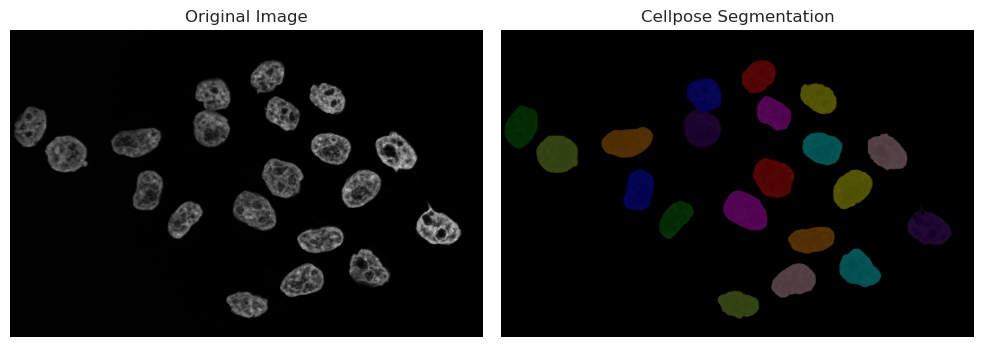

In [5]:
# We split the visualization here so that we can change visualization options without having to recompute the segmentation
# Visualize result
from skimage.color import label2rgb

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_ch1, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
# plt.imshow(img_ch1, cmap="gray")
labels_rgb_c1 = label2rgb(
    label=masks_c1,
    image=img_ch1,
    bg_label=0,  # Needed to tell the function that 0 is background and should not be colored
)
plt.imshow(labels_rgb_c1)
plt.title("Cellpose Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

### Running Cellpose on cytoplasm

In [6]:
print("Now running Cellpose on the cytoplasm with a fixed diameter...")
model = models.Cellpose(gpu=True, model_type="cyto3")
masks_c2, flows_c2, styles_c2, diams_c2 = model.eval(
    img_ch2, diameter=200, channels=[0, 0]
)

Now running Cellpose on the cytoplasm with a fixed diameter...


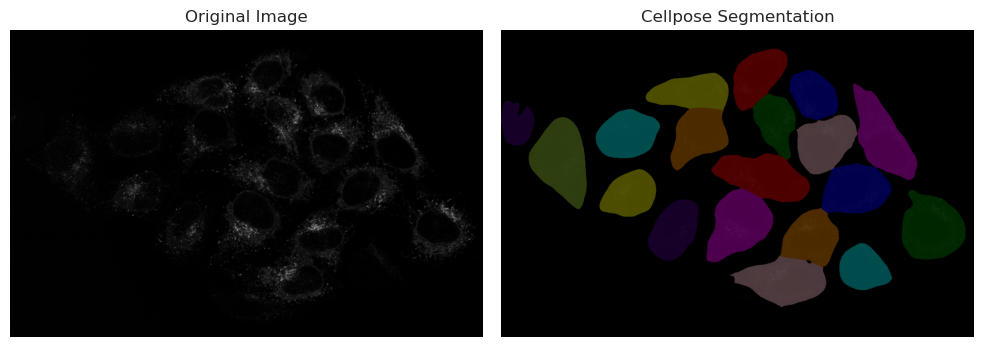

In [7]:
# We split the visualization here so that we can change visualization options without having to recompute the segmentation
# Visualize result
from skimage.color import label2rgb

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_ch2, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
# plt.imshow(img_ch1, cmap="gray")
labels_rgb_c2 = label2rgb(
    label=masks_c2,
    image=img_ch2,
    bg_label=0,  # Needed to tell the function that 0 is background and should not be colored
)
plt.imshow(labels_rgb_c2)
plt.title("Cellpose Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

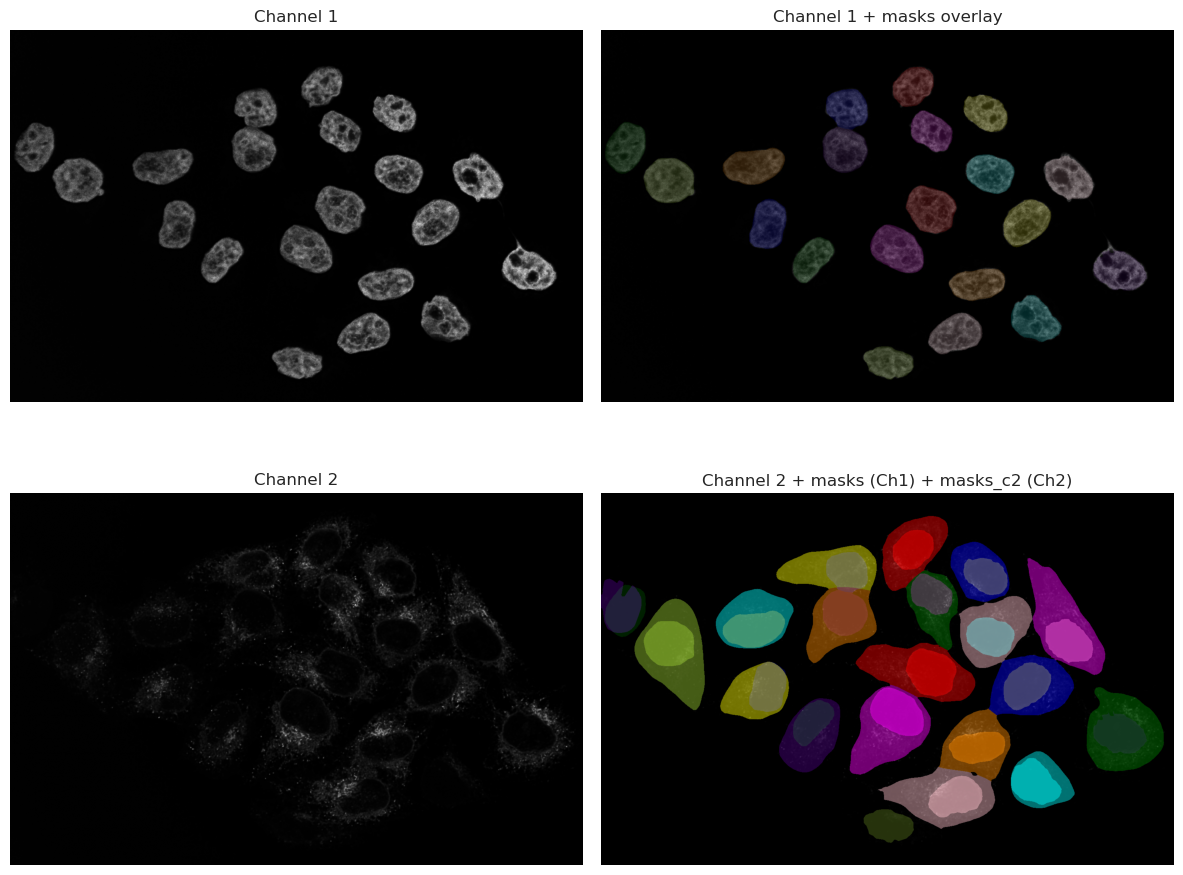

In [8]:
# We split the visualization here so that we can change visualization options without having to recompute the segmentation
# Visualize result in a 2x2 grid:
# [0,0] img_ch1, [0,1] img_ch1 + masks overlay
# [1,0] img_ch2, [1,1] img_ch2 + masks + masks_c2 overlay
from skimage.color import label2rgb
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top-left: Channel 1 original
axes[0, 0].imshow(img_ch1, cmap="gray")
axes[0, 0].set_title("Channel 1")
axes[0, 0].axis("off")

# Top-right: Channel 1 with masks overlay
labels_rgb_ch1 = label2rgb(label=masks_c1, image=img_ch1, bg_label=0)
axes[0, 1].imshow(img_ch1, cmap="gray")
axes[0, 1].imshow(labels_rgb_ch1, alpha=0.5)
axes[0, 1].set_title("Channel 1 + masks overlay")
axes[0, 1].axis("off")

# Bottom-left: Channel 2 original
axes[1, 0].imshow(img_ch2, cmap="gray")
axes[1, 0].set_title("Channel 2")
axes[1, 0].axis("off")

# Bottom-right: Channel 2 with masks (from ch1) and masks_c2 overlayed
# Create colored mask images for each label image
labels_rgb_masks = label2rgb(label=masks_c1, bg_label=0)
labels_rgb_masks_c2 = label2rgb(label=masks_c2, bg_label=0)
axes[1, 1].imshow(img_ch2, cmap="gray")
axes[1, 1].imshow(labels_rgb_masks, alpha=0.45)
axes[1, 1].imshow(labels_rgb_masks_c2, alpha=0.45)
axes[1, 1].set_title("Channel 2 + masks (Ch1) + masks_c2 (Ch2)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

As you can see, the results are much better than the thresholding method. The
model is able to recognize the nuclei even when they are dim, and it can also
segment the cytoplasm around them. This is because the model has been trained on
a large dataset of microscopy images, and it has learned to recognize the
features of cells and nuclei.

However, it is important to note that the model is not perfect, and it may still
miss some cells or segment some cells incorrectly. It is always a good idea to
visually inspect the results and make sure they are reasonable before proceeding
with further analysis.

Looking at the image, we can spot that one cell in the bottom right corner is
not segmented. This is because the signal in that cell is very dim, and the
model was not able to recognize it as a cell. This is a common issue with
deep-learning models, and it highlights the importance of having good quality
images for analysis.

In this case, since the nuclei was correctly segmented, we can use the nuclei segmentation as a seed in Cellpose, which will help the model to find the correct cell boundaries even in cases where the signal is dim. This is a common technique used in microscopy image analysis, where the nuclei segmentation is used as a guide for segmenting the cytoplasm.

### Running cellpose on cytoplasm using nuclei as seeds

In [9]:
# Read the first line you drew: shape is [[y0, x0], [y1, x1]]
print("Now running Cellpose on the cytoplasm with a nuclei channel input as well...")
model = models.Cellpose(gpu=True, model_type="cyto3")
masks_c2c1, flows_c2c1, styles_c2c1, diams_c2c1 = model.eval(
    img, diameter=200, channels=[2, 1]
)


Now running Cellpose on the cytoplasm with a nuclei channel input as well...


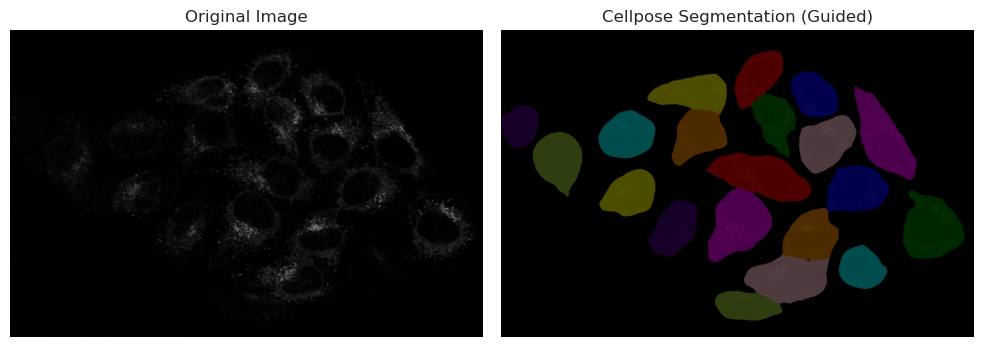

In [10]:
# We split the visualization here so that we can change visualization options without having to recompute the segmentation
# Visualize result
from skimage.color import label2rgb

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_ch2, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
# plt.imshow(img_ch1, cmap="gray")
labels_rgb_c2c1 = label2rgb(
    label=masks_c2c1,
    image=img_ch2,
    bg_label=0,  # Needed to tell the function that 0 is background and should not be colored
)
# Use the correct variable name for the guided segmentation
plt.imshow(labels_rgb_c2c1)
plt.title("Cellpose Segmentation (Guided)")
plt.axis("off")

plt.tight_layout()
plt.show()


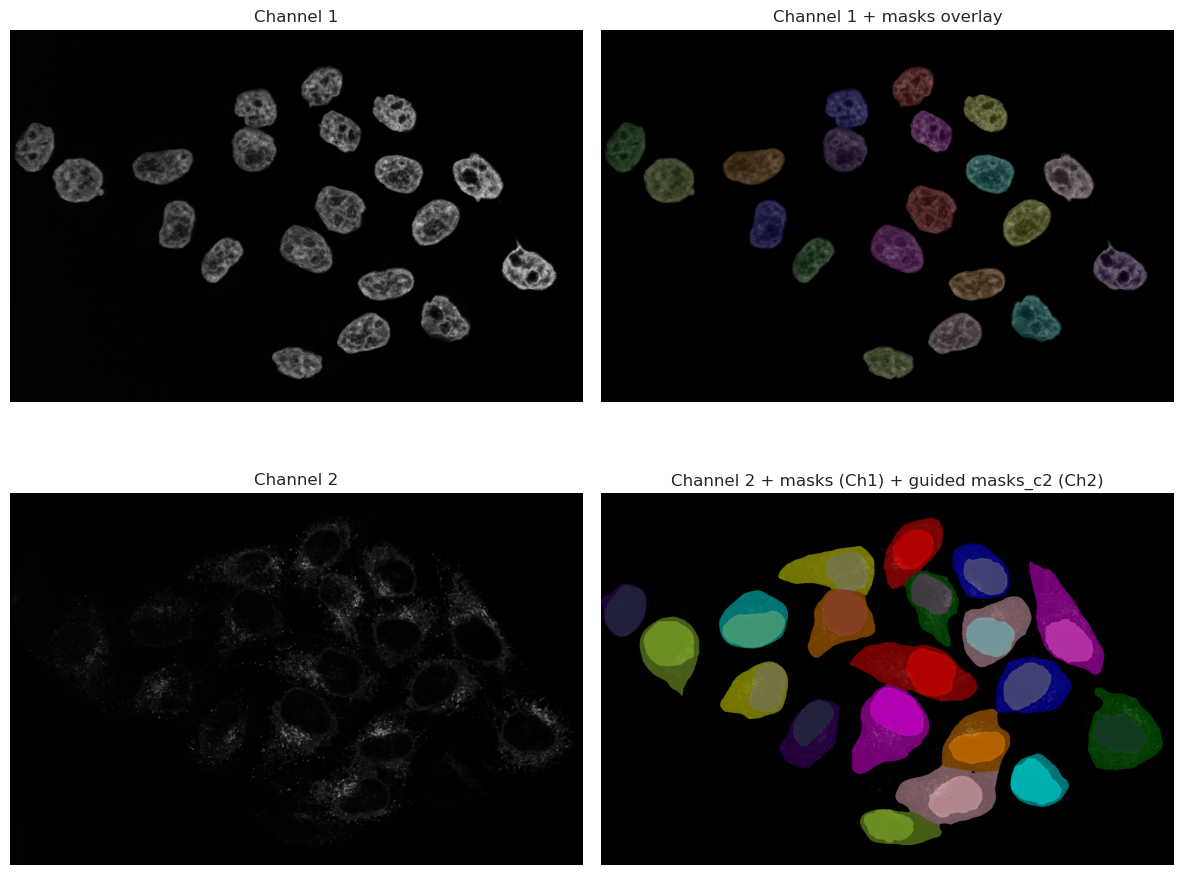

In [11]:
# We split the visualization here so that we can change visualization options without having to recompute the segmentation
# Visualize result in a 2x2 grid:
# [0,0] img_ch1, [0,1] img_ch1 + masks overlay
# [1,0] img_ch2, [1,1] img_ch2 + masks + masks_c2 overlay
from skimage.color import label2rgb
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top-left: Channel 1 original
axes[0, 0].imshow(img_ch1, cmap="gray")
axes[0, 0].set_title("Channel 1")
axes[0, 0].axis("off")

# Top-right: Channel 1 with masks overlay
labels_rgb_ch1 = label2rgb(label=masks_c1, image=img_ch1, bg_label=0)
axes[0, 1].imshow(img_ch1, cmap="gray")
axes[0, 1].imshow(labels_rgb_ch1, alpha=0.5)
axes[0, 1].set_title("Channel 1 + masks overlay")
axes[0, 1].axis("off")

# Bottom-left: Channel 2 original
axes[1, 0].imshow(img_ch2, cmap="gray")
axes[1, 0].set_title("Channel 2")
axes[1, 0].axis("off")

# Bottom-right: Channel 2 with masks (from ch1) and masks_c2 overlayed
# Create colored mask images for each label image
labels_rgb_masks = label2rgb(label=masks_c1, bg_label=0)
labels_rgb_masks_c2c1 = label2rgb(label=masks_c2c1, bg_label=0)
axes[1, 1].imshow(img_ch2, cmap="gray")
axes[1, 1].imshow(labels_rgb_masks, alpha=0.45)
axes[1, 1].imshow(labels_rgb_masks_c2c1, alpha=0.45)
axes[1, 1].set_title("Channel 2 + masks (Ch1) + guided masks_c2 (Ch2)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## Feature Extraction

Once we have segmented our objects, we can extract features from them. 
As the result from Cellpose is a label image (an image where each object has a
unique label), we can use this image to extract various features for each
segmented object. Common features include:
- **Area**: The number of pixels that belong to the object.
- **Perimeter**: The length of the boundary of the object.
- **Centroid**: The center of mass of the object.
- **Mean Intensity**: The average intensity of the pixels that belong to the object.
- **Ferret Diameter**: The diameter of a circle with the same area as the object.

This can be done using the `regionprops_table` function from `skimage.measure`. This function takes the raw image and a labeled image and returns a list of properties for each object.

In [12]:
props_nuclei = regionprops_table(
    label_image=masks_c1,
    intensity_image=img_ch1,
    properties=[
        "area",
        "perimeter",
        "centroid",
        "intensity_mean",
        "feret_diameter_max",
    ],
)
# Convert to DataFrame, rename intensity column to indicate channel, and round
df_props_nuclei = (
    pd.DataFrame(props_nuclei)
    .rename(columns={"intensity_mean": "intensity_mean_ch1"})
    .round(2)
)
display(df_props_nuclei.head())

,area,perimeter,centroid-0,centroid-1,intensity_mean_ch1,feret_diameter_max
0,9131.0,359.85,155.31,847.76,1924.41,122.97
1,9782.0,374.63,215.19,669.71,1849.23,125.90
2,9016.0,371.36,226.81,1045.77,2467.11,132.00
3,9092.0,370.92,277.43,897.39,1976.25,128.97
4,11504.0,410.03,320.99,67.04,1508.59,143.14


In [13]:
props_cells = regionprops_table(
    label_image=masks_c2c1,
    intensity_image=img_ch2,
    properties=[
        "area",
        "perimeter",
        "centroid",
        "intensity_mean",
        "feret_diameter_max",
    ],
)
# Convert to DataFrame, rename intensity column to indicate channel, and round
df_props_c2 = (
    pd.DataFrame(props_cells)
    .rename(columns={"intensity_mean": "intensity_mean_ch2"})
    .round(2)
)
display(df_props_c2.head())

,area,perimeter,centroid-0,centroid-1,intensity_mean_ch2,feret_diameter_max
0,19747.0,580.30,157.49,844.81,526.01,225.21
1,17765.0,512.17,216.10,1031.06,565.58,182.26
2,22773.0,687.14,210.31,632.21,492.07,264.39
3,31747.0,846.58,356.54,1257.74,484.20,358.43
4,18662.0,602.06,300.90,901.69,743.98,221.56


As you can see, the DataFrame contains the extracted features for each nucleus. We can do the same for the cells segmented in Channel 2. We can also match the nuclei and cells together to see which nucleus belongs to which cell, and extract features from both together.

In [14]:
# Match nuclei to cells and extract combined features
# Goal: Create a unified dataset where each cell record includes both cell and nucleus properties
from skimage.measure import regionprops
import numpy as np

# Extract mean intensities for nuclei and cells across both channels
# This allows us to compare signal levels in different compartments
nuc_props_ch1 = {
    p.label: p.intensity_mean for p in regionprops(masks_c1, intensity_image=img[0])
}
nuc_props_ch2 = {
    p.label: p.intensity_mean for p in regionprops(masks_c1, intensity_image=img[1])
}
cell_props_ch1 = {
    p.label: p.intensity_mean for p in regionprops(masks_c2c1, intensity_image=img[0])
}
cell_props_ch2 = {
    p.label: p.intensity_mean for p in regionprops(masks_c2c1, intensity_image=img[1])
}

# Build a lookup dictionary for nucleus properties by label
# This makes it fast to retrieve nucleus data when processing cells
nuc_lookup = {}
for p in regionprops(masks_c1):
    nuc_lookup[p.label] = {
        "nuclei_label": int(p.label),
        "nuclei_area": float(p.area),
        "nuclei_centroid_row": float(p.centroid[0]),
        "nuclei_centroid_col": float(p.centroid[1]),
        "nuclei_intensity_mean_ch1": nuc_props_ch1.get(p.label, np.nan),
        "nuclei_intensity_mean_ch2": nuc_props_ch2.get(p.label, np.nan),
    }

# For each cell, find the overlapping nucleus with maximum pixel count
# The assumption: the nucleus that overlaps most with a cell belongs to that cell
rows = []
for c in regionprops(masks_c2c1):
    cell_label = int(c.label)

    # Find which nucleus labels overlap with this cell's pixels
    overlap = masks_c1[masks_c2c1 == cell_label]
    labels, counts = np.unique(overlap, return_counts=True)

    # Identify the nucleus with the highest pixel overlap (best match)
    matched_n = 0  # Default: no nucleus found
    if labels.size > 0:
        nz = labels != 0  # Exclude background (label 0)
        if nz.any():
            matched_n = int(labels[nz][np.argmax(counts[nz])])

    # Collect cell properties
    cell_row = {
        "cell_label": cell_label,
        "cell_area": float(c.area),
        "cell_centroid_row": float(c.centroid[0]),
        "cell_centroid_col": float(c.centroid[1]),
        "cell_perimeter": float(getattr(c, "perimeter", np.nan)),
        "cell_intensity_mean_ch1": cell_props_ch1.get(cell_label, np.nan),
        "cell_intensity_mean_ch2": cell_props_ch2.get(cell_label, np.nan),
        "cell_feret_diameter_max": float(getattr(c, "feret_diameter_max", np.nan)),
        "matched_nucleus_label": matched_n,
    }

    # Merge nucleus data if a match was found
    # This creates a single row with both cell and nucleus information
    if matched_n and matched_n in nuc_lookup:
        cell_row.update(nuc_lookup[matched_n])
    else:
        # If no nucleus, fill nucleus columns with NaN
        cell_row.update(
            {
                "nuclei_label": np.nan,
                "nuclei_area": np.nan,
                "nuclei_centroid_row": np.nan,
                "nuclei_centroid_col": np.nan,
                "nuclei_intensity_mean_ch1": np.nan,
                "nuclei_intensity_mean_ch2": np.nan,
            }
        )

    rows.append(cell_row)

# Convert results to a DataFrame for easy analysis and visualization
df_matched = pd.DataFrame(rows).round(2)
display(df_matched.head())

,cell_label,cell_area,cell_centroid_row,cell_centroid_col,cell_perimeter,cell_intensity_mean_ch1,cell_intensity_mean_ch2,cell_feret_diameter_max,matched_nucleus_label,nuclei_label,nuclei_area,nuclei_centroid_row,nuclei_centroid_col,nuclei_intensity_mean_ch1,nuclei_intensity_mean_ch2
0,1,19747.0,157.49,844.81,580.30,925.57,526.01,225.21,1,1,9131.0,155.31,847.76,1924.41,374.05
1,2,17765.0,216.10,1031.06,512.17,1293.11,565.58,182.26,3,3,9016.0,226.81,1045.77,2467.11,344.76
2,3,22773.0,210.31,632.21,687.14,821.32,492.07,264.39,2,2,9782.0,215.19,669.71,1849.23,476.10
3,4,31747.0,356.54,1257.74,846.58,1005.74,484.20,358.43,9,9,11190.0,404.92,1270.65,2601.78,106.44
4,5,18662.0,300.90,901.69,602.06,996.47,743.98,221.56,4,4,9092.0,277.43,897.39,1976.25,757.83


## Deep Dive: Biological Explorations

Once we have managed to get this far, we can move beyond simple measurement and start testing biological hypotheses using our extracted features in `df_matched`. The possibilities are endless, and it really depends on your specific question and what you are trying to understand from your data.

In the following sections, we will explore several "cool" questions you can ask your data.


### Question A: What is the average size of my nuclei and cells? 
Are they different? Are they different between conditions?


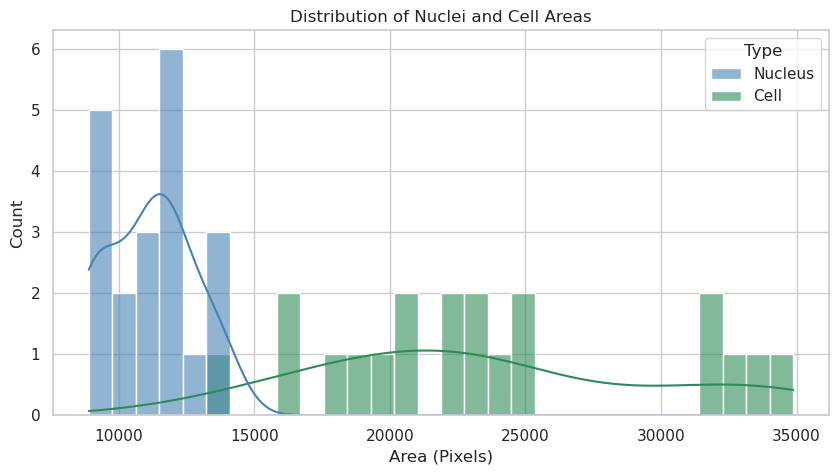

Nuclei: n=20, mean area=11100.7 px
Cells:  n=20, mean area=23618.5 px


In [15]:
from skimage.measure import regionprops

# Choose available labels
nuc_labels = masks_c1
cell_labels = masks_c2c1

# Collect areas
nuc_areas = [p.area for p in regionprops(nuc_labels)]
cell_areas = [p.area for p in regionprops(cell_labels)]

# Create a DataFrame for Seaborn
df_areas = pd.DataFrame(
    {
        "Area": nuc_areas + cell_areas,
        "Type": ["Nucleus"] * len(nuc_areas) + ["Cell"] * len(cell_areas),
    }
)

# Plotting code with Seaborn
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_areas,
    x="Area",
    hue="Type",
    kde=True,
    bins=30,
    palette=["steelblue", "seagreen"],
    alpha=0.6,
)
plt.title("Distribution of Nuclei and Cell Areas")
plt.xlabel("Area (Pixels)")
plt.ylabel("Count")
plt.show()

print(f"Nuclei: n={len(nuc_areas)}, mean area={sum(nuc_areas) / len(nuc_areas):.1f} px")
print(
    f"Cells:  n={len(cell_areas)}, mean area={sum(cell_areas) / len(cell_areas):.1f} px"
)

**Answer A:**
The nuclei and cells show distinct area distributions. Nuclei appear to have a more constrained size range, while cell areas exhibit greater variability. This likely reflects the biological reality where nuclear size is tightly regulated, whereas cytoplasmic volume can vary significantly depending on growth conditions or cell state.


### Question B: Is the size of the nucleus relative to the size of the cell?
We can investigate the ratio of nuclear to cytoplasmic area to see if there is a consistent relationship.


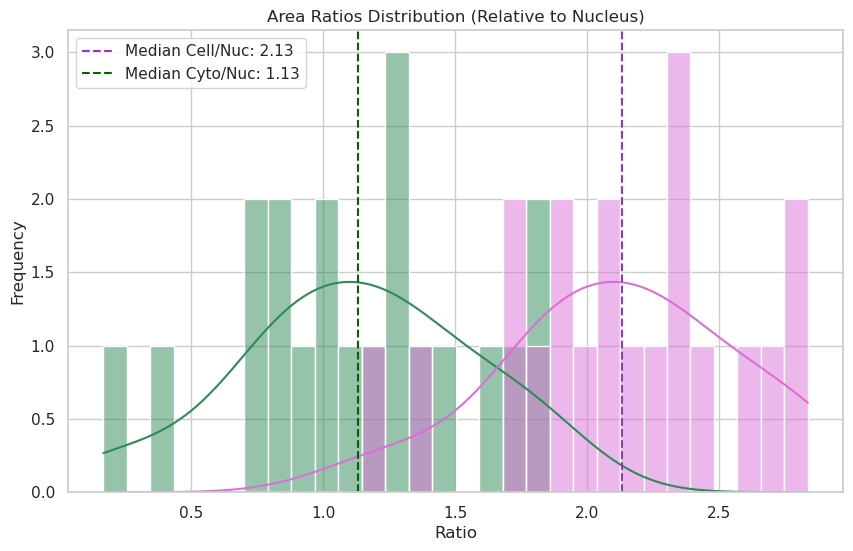

Median Cell/Nuclei ratio: 2.13
Median Cyto/Nuclei ratio: 1.13


In [16]:
# Use df_matched to compute cell/nuclei and cyto/nuclei area ratios
# Cytoplasm = Cell - Nucleus
df_matched["cytoplasm_area"] = df_matched["cell_area"] - df_matched["nuclei_area"]

# Cell to Nuclei ratio
df_matched["cell_nuc_ratio"] = df_matched["cell_area"] / df_matched["nuclei_area"]
# Cytoplasm to Nuclei ratio
df_matched["cyto_nuc_ratio"] = df_matched["cytoplasm_area"] / df_matched["nuclei_area"]

# Filter for valid entries (where nuclei exist and ratios are finite)
valid_data = df_matched.dropna(subset=["cell_nuc_ratio", "cyto_nuc_ratio"])
valid_data = valid_data[
    np.isfinite(valid_data["cell_nuc_ratio"])
    & np.isfinite(valid_data["cyto_nuc_ratio"])
]

# Prepare data for plotting
df_ratios_melted = valid_data.melt(
    value_vars=["cell_nuc_ratio", "cyto_nuc_ratio"],
    var_name="Ratio Type",
    value_name="Ratio",
)

# Visualize the distribution with Seaborn
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_ratios_melted,
    x="Ratio",
    hue="Ratio Type",
    bins=30,
    kde=True,
    palette=["orchid", "seagreen"],
    alpha=0.5,
)

# Calculate medians for visualization
cell_med = valid_data["cell_nuc_ratio"].median()
cyto_med = valid_data["cyto_nuc_ratio"].median()

# Add median lines
plt.axvline(
    cell_med,
    color="darkorchid",
    linestyle="--",
    label=f"Median Cell/Nuc: {cell_med:.2f}",
)
plt.axvline(
    cyto_med,
    color="darkgreen",
    linestyle="--",
    label=f"Median Cyto/Nuc: {cyto_med:.2f}",
)

plt.title("Area Ratios Distribution (Relative to Nucleus)")
plt.xlabel("Ratio")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(f"Median Cell/Nuclei ratio: {cell_med:.2f}")
print(f"Median Cyto/Nuclei ratio: {cyto_med:.2f}")

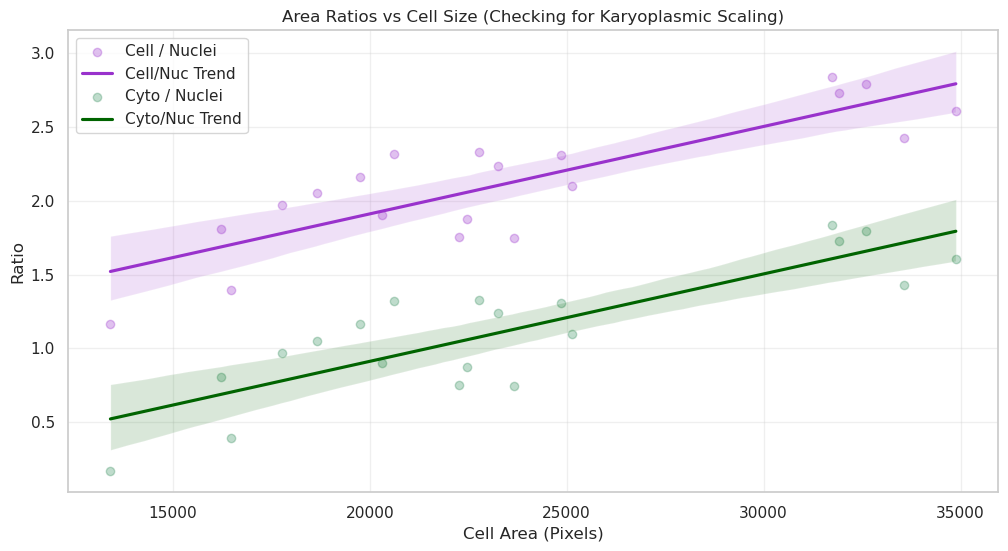

In [17]:
# Sorting by cell area and plotting ratios
sorted_data = valid_data.sort_values("cell_area").reset_index(drop=True)

# Visualize with Seaborn and add a regression line to see how the ratio changes
plt.figure(figsize=(12, 6))

# Plotting with scatter and a smooth line or linear trend to show scaling
sns.regplot(
    data=sorted_data,
    x="cell_area",
    y="cell_nuc_ratio",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "darkorchid", "label": "Cell/Nuc Trend"},
    label="Cell / Nuclei",
    color="darkorchid",
)
sns.regplot(
    data=sorted_data,
    x="cell_area",
    y="cyto_nuc_ratio",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "darkgreen", "label": "Cyto/Nuc Trend"},
    label="Cyto / Nuclei",
    color="seagreen",
)

plt.title("Area Ratios vs Cell Size (Checking for Karyoplasmic Scaling)")
plt.xlabel("Cell Area (Pixels)")
plt.ylabel("Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Answer B:**
By sorting cells by size, we can see if the ratio remains constant. If the ratio is stable, it implies "karyoplasmic scaling"—where the nucleus grows in proportion to the cell. Deviations in the ratio for very large or small cells might indicate specific biological phases, such as preparation for division.


### Question C: What is the average intensity of my nuclei and cells? 
Are they different? Are they different between conditions?

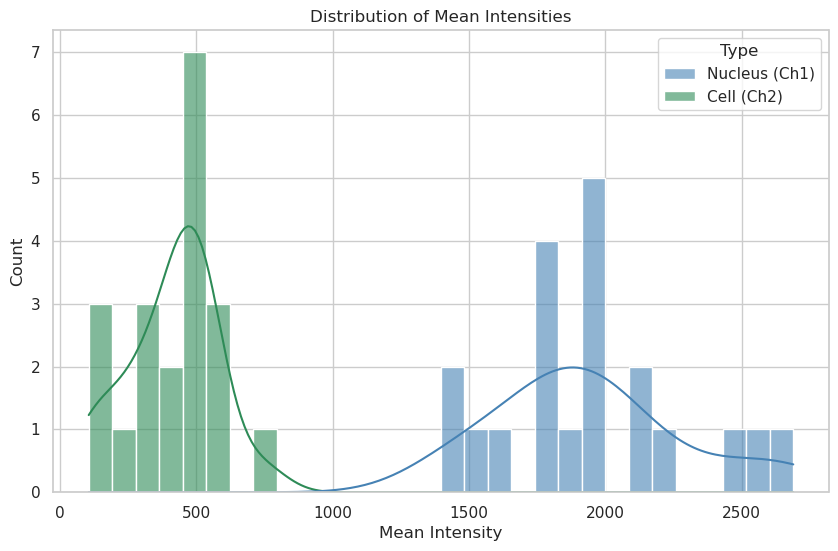

Nuclei: n=20, mean=1943.40
Cells:  n=20, mean=410.32


In [18]:
from skimage.measure import regionprops

# Choose available labels
nuc_labels = masks_c1
cell_labels = masks_c2c1

# Collect mean intensities
nuc_means = [p.intensity_mean for p in regionprops(nuc_labels, intensity_image=img_ch1)]
cell_means = [
    p.intensity_mean for p in regionprops(cell_labels, intensity_image=img_ch2)
]

# Combine intensities for Seaborn
df_intensities = pd.DataFrame(
    {
        "Intensity": nuc_means + cell_means,
        "Type": ["Nucleus (Ch1)"] * len(nuc_means) + ["Cell (Ch2)"] * len(cell_means),
    }
)

# Visualize using Seaborn
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_intensities,
    x="Intensity",
    hue="Type",
    kde=True,
    bins=30,
    palette=["steelblue", "seagreen"],
    alpha=0.6,
)

plt.title("Distribution of Mean Intensities")
plt.xlabel("Mean Intensity")
plt.ylabel("Count")
plt.show()

print(f"Nuclei: n={len(nuc_means)}, mean={sum(nuc_means) / len(nuc_means):.2f}")
print(f"Cells:  n={len(cell_means)}, mean={sum(cell_means) / len(cell_means):.2f}")

**Answer C:**
Mean intensity distributions reveal the concentration of signal in each compartment. A narrower peak suggests uniform protein expression across the population, while a broad or multi-modal distribution could indicate sub-populations of cells with different expression levels or metabolic states.

### Question D: Nuclear "Crowding" vs. Activity
**Question:** In cells where the nucleus is very large relative to the cytoplasm (High Nuc/Cell ratio), is the metabolic activity (simulated here by Channel 3 intensity) higher or lower?
*This could indicate cell-cycle stages or stress responses.*

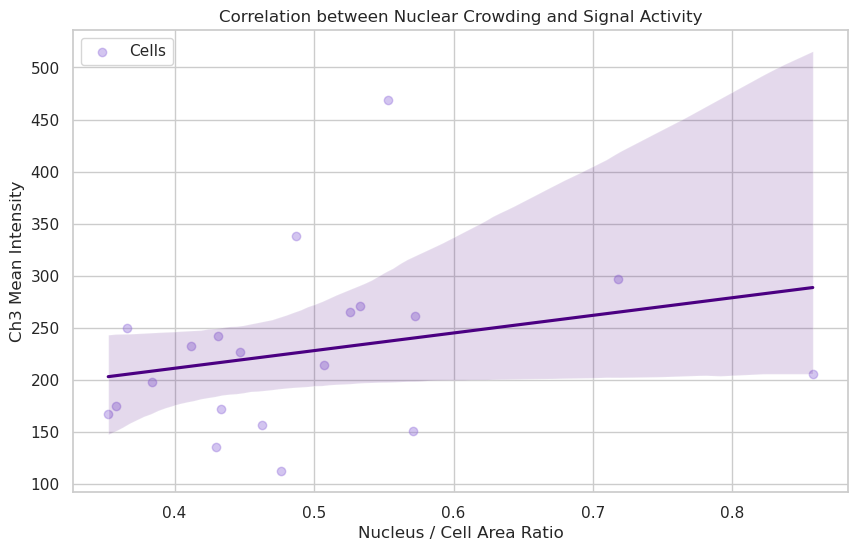

Correlation coefficient: 0.26


In [19]:
from skimage.measure import regionprops

# Prepare additional features in df_matched
ch3_props = {
    p.label: p.intensity_mean for p in regionprops(masks_c2c1, intensity_image=img[2])
}
df_matched["cell_intensity_mean_ch3"] = df_matched["cell_label"].map(ch3_props)
df_matched["nuc_cell_area_ratio"] = df_matched["nuclei_area"] / df_matched["cell_area"]

# --- Plot: Nuclear "Crowding" vs. Activity ---
plt.figure(figsize=(10, 6))

# Visualize with joint distribution for more insights
sns.regplot(
    data=df_matched,
    x="nuc_cell_area_ratio",
    y="cell_intensity_mean_ch3",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "indigo"},
    color="mediumpurple",
    label="Cells",
)

plt.title("Correlation between Nuclear Crowding and Signal Activity")
plt.xlabel("Nucleus / Cell Area Ratio")
plt.ylabel("Ch3 Mean Intensity")
plt.legend()
plt.show()

print(
    f"Correlation coefficient: {df_matched[['nuc_cell_area_ratio', 'cell_intensity_mean_ch3']].corr().iloc[0, 1]:.2f}"
)

**Answer D:** 
If the trendline is flat or the correlation is low (near 0), it suggests that the concentration of the protein in Channel 3 is independent of how "crowded" the cell is by its nucleus. If the correlation is high, it might suggest that smaller, more compact cells (higher ratio) have higher metabolic concentrations.

### Question E: Signal Localization: Is it the same everywhere?
**Question:** Does the intensity of Channel 2 (Cytoplasm) correlate perfectly with Channel 1 (Nuclei)?
*Strong correlation suggests a leaked or non-specific signal, while low correlation suggests distinct functional compartments.*

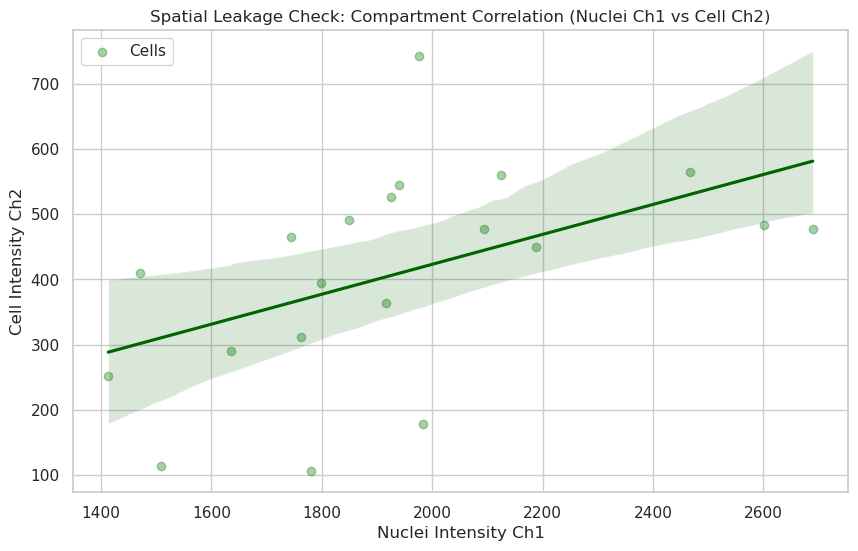

Correlation coefficient: 0.49


In [20]:
# --- Plot: Signal Localization Correlation (Ch1 vs Ch2) ---
plt.figure(figsize=(10, 6))

# Visualize with joint distribution for more insights
# Use Nuclei Intensity Ch1 vs Cell Intensity Ch2 to compare compartmental biology
sns.regplot(
    data=df_matched,
    x="nuclei_intensity_mean_ch1",
    y="cell_intensity_mean_ch2",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "darkgreen"},
    color="forestgreen",
    label="Cells",
)

plt.title("Spatial Leakage Check: Compartment Correlation (Nuclei Ch1 vs Cell Ch2)")
plt.xlabel("Nuclei Intensity Ch1")
plt.ylabel("Cell Intensity Ch2")
plt.legend()
plt.show()

print(
    f"Correlation coefficient: {df_matched[['nuclei_intensity_mean_ch1', 'cell_intensity_mean_ch2']].corr().iloc[0, 1]:.2f}"
)

**Answer E:**
A high correlation (e.g., > 0.8) often indicates that the signal is "leaking" or that the segmentation boundaries are not perfectly separating the compartments. A low correlation suggests that the biology in the nucleus (Ch1) is spatially and functionally distinct from the biology in the cytoplasm (Ch2).

### Question F: Morphology vs. Signal: Does Shape matter?
**Question:** Do elongated cells have different Channel 2 levels than round cells?
*We can calculate 'Roundness' to see if cell stretching affects expression.*

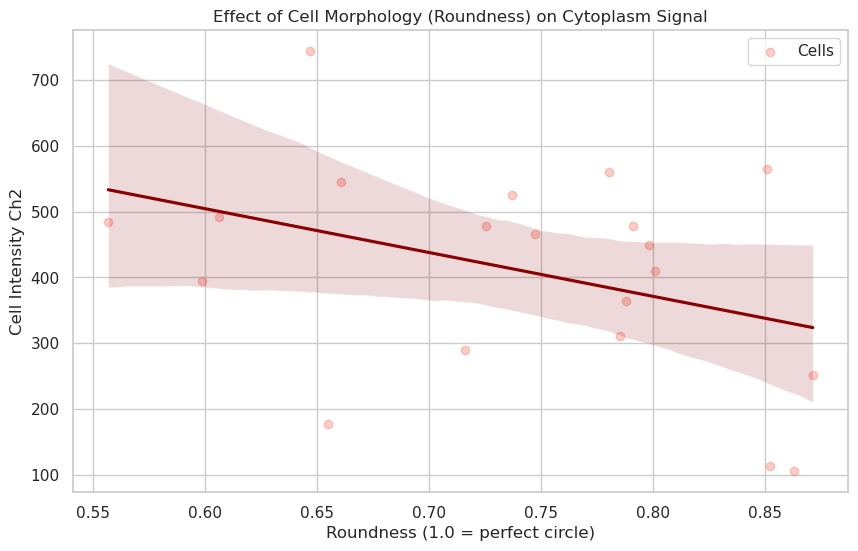

Correlation coefficient: -0.38


In [21]:
# --- Plot: Morphology (Roundness) vs. Signal ---
# Ensure Roundness is correctly calculated
df_matched["roundness"] = (4 * np.pi * df_matched["cell_area"]) / (
    df_matched["cell_perimeter"] ** 2
)

plt.figure(figsize=(10, 6))

# Visualize Roundness vs Signal Intensity
sns.regplot(
    data=df_matched,
    x="roundness",
    y="cell_intensity_mean_ch2",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "darkred"},
    color="salmon",
    label="Cells",
)

plt.title("Effect of Cell Morphology (Roundness) on Cytoplasm Signal")
plt.xlabel("Roundness (1.0 = perfect circle)")
plt.ylabel("Cell Intensity Ch2")
plt.legend()
plt.show()

print(
    f"Correlation coefficient: {df_matched[['roundness', 'cell_intensity_mean_ch2']].corr().iloc[0, 1]:.2f}"
)

**Answer F:**
Roundness measures how circular a cell is. If rounder cells (closer to 1.0) show higher intensities, it might indicate that cells in suspension or mitotic cells (which ball up) have different expression levels than spread-out, elongated cells. 

The correlation coefficient quantifies this relationship: a positive correlation implies rounder cells express more signal, while a near-zero correlation suggests that cell shape does not significantly affect the measured channel's expression level. Negative correlations would imply that large spreading structures or highly polarized shapes exhibit stronger intensity.

In [22]:
# Final Summary Table
print("Overview of measured features:")
display(df_matched[["cell_label", "cell_area", "nuclei_area", "roundness"]].head())

Overview of measured features:


,cell_label,cell_area,nuclei_area,roundness
0,1,19747.0,9131.0,0.736895
1,2,17765.0,9016.0,0.851034
2,3,22773.0,9782.0,0.606094
3,4,31747.0,11190.0,0.556643
4,5,18662.0,9092.0,0.646976
